# Rotom Policy

In [29]:
import mujoco
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.distributions import Normal

In [30]:
xml_path = "robot.xml"   # change if needed

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

actuator_names = ["O", "A", "B", "C"]
joint_names = ["O", "A", "B", "C"]

actuator_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, n) for n in actuator_names]
joint_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in joint_names]

qpos_ids = [model.jnt_qposadr[jid] for jid in joint_ids]
qvel_ids = [model.jnt_dofadr[jid] for jid in joint_ids]
joint_ranges = np.array([model.jnt_range[jid] for jid in joint_ids], dtype=np.float32)

print("actuator ids:", actuator_ids)
print("joint ranges:\n", joint_ranges)

actuator ids: [0, 1, 2, 3]
joint ranges:
 [[-1.787524   1.787524 ]
 [-3.141593   0.40507  ]
 [-0.0421948  3.141593 ]
 [-3.141593   0.377451 ]]


In [31]:
def get_q():
    return np.array([data.qpos[i] for i in qpos_ids], dtype=np.float32)

def get_qd():
    return np.array([data.qvel[i] for i in qvel_ids], dtype=np.float32)

def get_obs():
    q = get_q()
    qd = get_qd()
    
    q_mid = 0.5 * (joint_ranges[:, 0] + joint_ranges[:, 1])
    q_half = 0.5 * (joint_ranges[:, 1] - joint_ranges[:, 0])
    
    q_norm = (q - q_mid) / (q_half + 1e-6)
    target_norm = (target_q - q_mid) / (q_half + 1e-6)
    qd_norm = 0.1 * qd
    
    return np.concatenate([q_norm, qd_norm, target_norm], axis=0).astype(np.float32)

def reset_env():
    global data, target_q, step_count
    data = mujoco.MjData(model)
    step_count = 0
    
    q0 = np.array([np.random.uniform(lo, hi) for lo, hi in joint_ranges], dtype=np.float32)
    for i, qidx in enumerate(qpos_ids):
        data.qpos[qidx] = q0[i]
    mujoco.mj_forward(model, data)
    
    # easier target: nearby target, not anywhere in the full space
    target_q = q0 + np.random.uniform(-0.25, 0.25, size=4).astype(np.float32)
    for i in range(4):
        lo, hi = joint_ranges[i]
        target_q[i] = np.clip(target_q[i], lo, hi)
    
    return get_obs()

def step_env(action):
    global step_count
    
    q = get_q()
    
    # small joint increments
    delta_scale = np.array([0.05, 0.05, 0.05, 0.05], dtype=np.float32)
    ctrl = q + delta_scale * np.clip(action, -1.0, 1.0)
    
    # clamp to joint limits
    for i in range(4):
        lo, hi = joint_ranges[i]
        ctrl[i] = np.clip(ctrl[i], lo, hi)
    
    data.ctrl[:] = ctrl
    mujoco.mj_step(model, data)
    step_count += 1
    
    q = get_q()
    qd = get_qd()
    err = q - target_q
    
    reward = -np.linalg.norm(err)
    reward -= 0.01 * np.linalg.norm(qd)
    reward -= 0.001 * np.linalg.norm(action)
    
    done = False
    if np.linalg.norm(err) < 0.08:
        reward += 10.0
        done = True
    if step_count >= 100:
        done = True
    
    obs = np.concatenate([q, qd, target_q], axis=0).astype(np.float32)
    return obs, reward, done

In [32]:
obs = reset_env()
print("obs shape:", obs.shape)

for _ in range(5):
    a = np.random.uniform(-1, 1, size=4).astype(np.float32)
    obs, reward, done = step_env(a)
    print("reward:", reward, "done:", done)

obs shape: (12,)
reward: -0.29242077 done: False
reward: -0.29390553 done: False
reward: -0.2929987 done: False
reward: -0.29420978 done: False
reward: -0.29325956 done: False


In [33]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim=12, act_dim=4):
        super().__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
        )
        
        self.actor_mean = nn.Linear(64, act_dim)
        self.critic = nn.Linear(64, 1)
        
        self.log_std = nn.Parameter(torch.ones(act_dim) * -1.5)
    
    def forward(self, obs):
        x = self.shared(obs)
        mean = self.actor_mean(x)
        value = self.critic(x).squeeze(-1)
        std = torch.exp(self.log_std)
        return mean, std, value

net = ActorCritic()
optimizer = optim.Adam(net.parameters(), lr=3e-4)

In [34]:
obs_buf = []
act_buf = []
logp_buf = []
rew_buf = []
done_buf = []
val_buf = []

In [35]:
steps_per_rollout = 2048

obs = reset_env()

for _ in range(steps_per_rollout):
    obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
    
    with torch.no_grad():
        mean, std, value = net(obs_t)
        dist = Normal(mean, std)
        action_t = dist.sample()
        logp_t = dist.log_prob(action_t).sum(dim=-1)
    
    action = action_t.squeeze(0).numpy()
    next_obs, reward, done = step_env(action)
    
    obs_buf.append(obs.copy())
    act_buf.append(action.copy())
    logp_buf.append(logp_t.item())
    rew_buf.append(reward)
    done_buf.append(done)
    val_buf.append(value.item())
    
    obs = next_obs
    if done:
        obs = reset_env()

In [36]:
gamma = 0.99
lam = 0.95

obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    _, _, last_val = net(obs_t)
last_val = last_val.item()

rews = np.array(rew_buf, dtype=np.float32)
vals = np.array(val_buf + [last_val], dtype=np.float32)
dones = np.array(done_buf, dtype=np.float32)

advantages = np.zeros_like(rews, dtype=np.float32)
gae = 0.0

for t in reversed(range(len(rews))):
    nonterminal = 1.0 - dones[t]
    delta = rews[t] + gamma * vals[t+1] * nonterminal - vals[t]
    gae = delta + gamma * lam * nonterminal * gae
    advantages[t] = gae

returns = advantages + vals[:-1]

advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

obs_tensor = torch.tensor(np.array(obs_buf), dtype=torch.float32)
act_tensor = torch.tensor(np.array(act_buf), dtype=torch.float32)
logp_old_tensor = torch.tensor(np.array(logp_buf), dtype=torch.float32)
adv_tensor = torch.tensor(advantages, dtype=torch.float32)
ret_tensor = torch.tensor(returns, dtype=torch.float32)

print(obs_tensor.shape, act_tensor.shape)

torch.Size([2048, 12]) torch.Size([2048, 4])


In [37]:
clip_eps = 0.2
train_iters = 10
batch_size = 256

N = obs_tensor.shape[0]
idxs = np.arange(N)

for _ in range(train_iters):
    np.random.shuffle(idxs)
    
    for start in range(0, N, batch_size):
        batch_idx = idxs[start:start+batch_size]
        
        b_obs = obs_tensor[batch_idx]
        b_act = act_tensor[batch_idx]
        b_logp_old = logp_old_tensor[batch_idx]
        b_adv = adv_tensor[batch_idx]
        b_ret = ret_tensor[batch_idx]
        
        mean, std, value = net(b_obs)
        dist = Normal(mean, std)
        logp = dist.log_prob(b_act).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1).mean()
        
        ratio = torch.exp(logp - b_logp_old)
        surr1 = ratio * b_adv
        surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * b_adv
        actor_loss = -torch.min(surr1, surr2).mean()
        
        critic_loss = ((value - b_ret) ** 2).mean()
        
        loss = actor_loss + 0.5 * critic_loss - 0.001 * entropy
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("ppo update done")

ppo update done


In [38]:
reward_history = []

epochs = 30
steps_per_rollout = 2048

for epoch in range(epochs):
    obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []
    
    obs = reset_env()
    ep_rewards = []
    current_ep_reward = 0.0
    
    for _ in range(steps_per_rollout):
        obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            mean, std, value = net(obs_t)
            dist = Normal(mean, std)
            action_t = dist.sample()
            logp_t = dist.log_prob(action_t).sum(dim=-1)
        
        action = action_t.squeeze(0).numpy()
        next_obs, reward, done = step_env(action)
        
        obs_buf.append(obs.copy())
        act_buf.append(action.copy())
        logp_buf.append(logp_t.item())
        rew_buf.append(reward)
        done_buf.append(done)
        val_buf.append(value.item())
        
        current_ep_reward += reward
        obs = next_obs
        
        if done:
            ep_rewards.append(current_ep_reward)
            current_ep_reward = 0.0
            obs = reset_env()
    
    obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        _, _, last_val = net(obs_t)
    last_val = last_val.item()
    
    rews = np.array(rew_buf, dtype=np.float32)
    vals = np.array(val_buf + [last_val], dtype=np.float32)
    dones = np.array(done_buf, dtype=np.float32)
    
    advantages = np.zeros_like(rews, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(len(rews))):
        nonterminal = 1.0 - dones[t]
        delta = rews[t] + 0.99 * vals[t+1] * nonterminal - vals[t]
        gae = delta + 0.99 * 0.95 * nonterminal * gae
        advantages[t] = gae
    
    returns = advantages + vals[:-1]
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    
    obs_tensor = torch.tensor(np.array(obs_buf), dtype=torch.float32)
    act_tensor = torch.tensor(np.array(act_buf), dtype=torch.float32)
    logp_old_tensor = torch.tensor(np.array(logp_buf), dtype=torch.float32)
    adv_tensor = torch.tensor(advantages, dtype=torch.float32)
    ret_tensor = torch.tensor(returns, dtype=torch.float32)
    
    N = obs_tensor.shape[0]
    idxs = np.arange(N)
    
    for _ in range(10):
        np.random.shuffle(idxs)
        for start in range(0, N, 256):
            batch_idx = idxs[start:start+256]
            
            b_obs = obs_tensor[batch_idx]
            b_act = act_tensor[batch_idx]
            b_logp_old = logp_old_tensor[batch_idx]
            b_adv = adv_tensor[batch_idx]
            b_ret = ret_tensor[batch_idx]
            
            mean, std, value = net(b_obs)
            dist = Normal(mean, std)
            logp = dist.log_prob(b_act).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1).mean()
            
            ratio = torch.exp(logp - b_logp_old)
            surr1 = ratio * b_adv
            surr2 = torch.clamp(ratio, 1 - 0.2, 1 + 0.2) * b_adv
            
            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = ((value - b_ret) ** 2).mean()
            loss = actor_loss + 0.5 * critic_loss - 0.001 * entropy
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    avg_reward = np.mean(ep_rewards) if len(ep_rewards) > 0 else current_ep_reward
    reward_history.append(avg_reward)
    print(f"epoch {epoch+1:02d} | avg ep reward {avg_reward:.3f}")

epoch 01 | avg ep reward -29.066
epoch 02 | avg ep reward -27.661
epoch 03 | avg ep reward -29.267
epoch 04 | avg ep reward -27.435
epoch 05 | avg ep reward -29.995
epoch 06 | avg ep reward -26.394
epoch 07 | avg ep reward -28.394
epoch 08 | avg ep reward -24.719
epoch 09 | avg ep reward -25.558
epoch 10 | avg ep reward -28.098
epoch 11 | avg ep reward -28.806
epoch 12 | avg ep reward -29.843
epoch 13 | avg ep reward -28.226
epoch 14 | avg ep reward -30.321
epoch 15 | avg ep reward -30.132
epoch 16 | avg ep reward -30.669
epoch 17 | avg ep reward -29.208
epoch 18 | avg ep reward -31.424
epoch 19 | avg ep reward -27.612
epoch 20 | avg ep reward -29.039
epoch 21 | avg ep reward -29.218
epoch 22 | avg ep reward -28.768
epoch 23 | avg ep reward -30.214
epoch 24 | avg ep reward -32.364
epoch 25 | avg ep reward -31.750
epoch 26 | avg ep reward -29.709
epoch 27 | avg ep reward -24.996
epoch 28 | avg ep reward -27.177
epoch 29 | avg ep reward -29.868
epoch 30 | avg ep reward -31.884


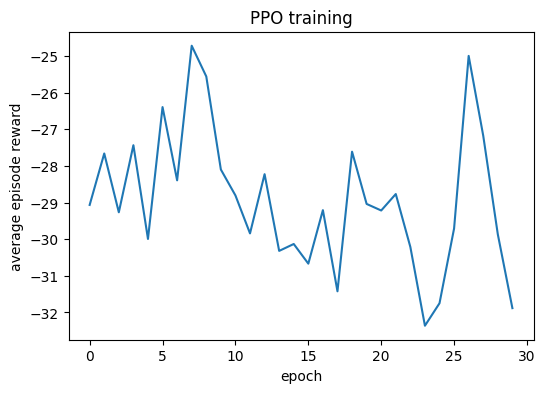

In [39]:
plt.figure(figsize=(6,4))
plt.plot(reward_history)
plt.xlabel("epoch")
plt.ylabel("average episode reward")
plt.title("PPO training")
plt.show()

In [40]:
obs = reset_env()

q_log = []
target_log = []

for _ in range(100):
    obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        mean, std, value = net(obs_t)
    
    action = mean.squeeze(0).numpy()   # deterministic eval
    obs, reward, done = step_env(action)
    
    q_log.append(get_q().copy())
    target_log.append(target_q.copy())
    
    if done:
        break

q_log = np.array(q_log)
target_log = np.array(target_log)

print("final q:", q_log[-1])
print("target q:", target_log[-1])
print("final error norm:", np.linalg.norm(q_log[-1] - target_log[-1]))

final q: [ 0.27959388 -2.4308605   2.0998235  -2.4484005 ]
target q: [ 0.14698452 -2.2122104   1.8990669  -2.2581613 ]
final error norm: 0.37667924


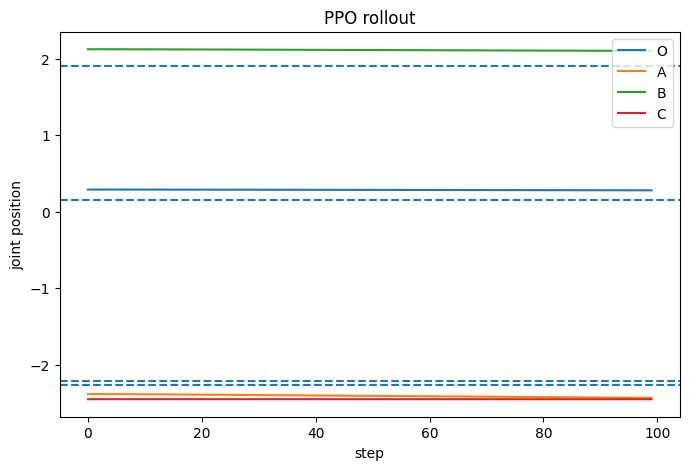

In [41]:
plt.figure(figsize=(8,5))
for i, name in enumerate(joint_names):
    plt.plot(q_log[:, i], label=f"{name}")
    plt.axhline(target_log[-1, i], linestyle="--")
plt.legend()
plt.xlabel("step")
plt.ylabel("joint position")
plt.title("PPO rollout")
plt.show()

In [42]:
torch.save(net.state_dict(), "ppo_small_robot.pt")
print("saved ppo_small_robot.pt")

saved ppo_small_robot.pt
